# Task 3: Exploratory Data Analysis (EDA)
**Internship:** Synent Technologies – Data Science Internship  
**Dataset:** Netflix Dataset  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**By:** Sneha Agarwal

## Objective
Identify trends and patterns in Netflix content through summary statistics, correlation analysis, and visualizations.

## Step 1: Import Libraries and load dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('netflix_titles.csv')

print(f"Shape: {df.shape}")
df.head()

Saving netflix_titles.csv to netflix_titles.csv
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 2: Summary Statistics

In [6]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
print(df.describe(include='all'))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

=== Missing Values ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration     

## Step 3: Movies vs TV Shows

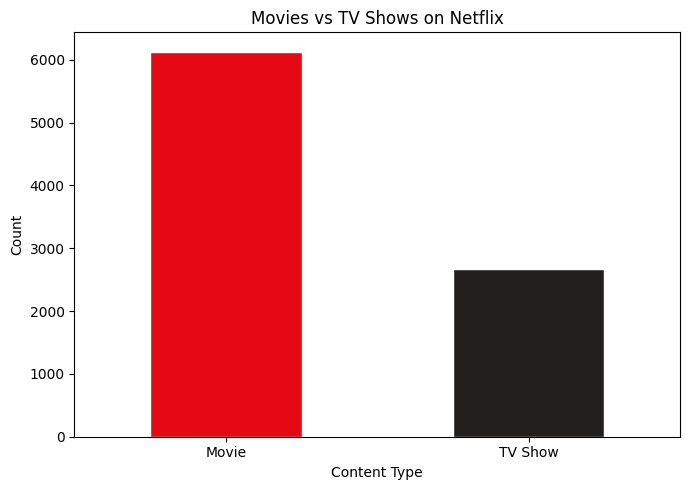

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(7, 5))
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221F1F'], edgecolor='white')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['type'].value_counts())

## Step 4: Top 10 Countries

/tmp/ipykernel_2633/2541412976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


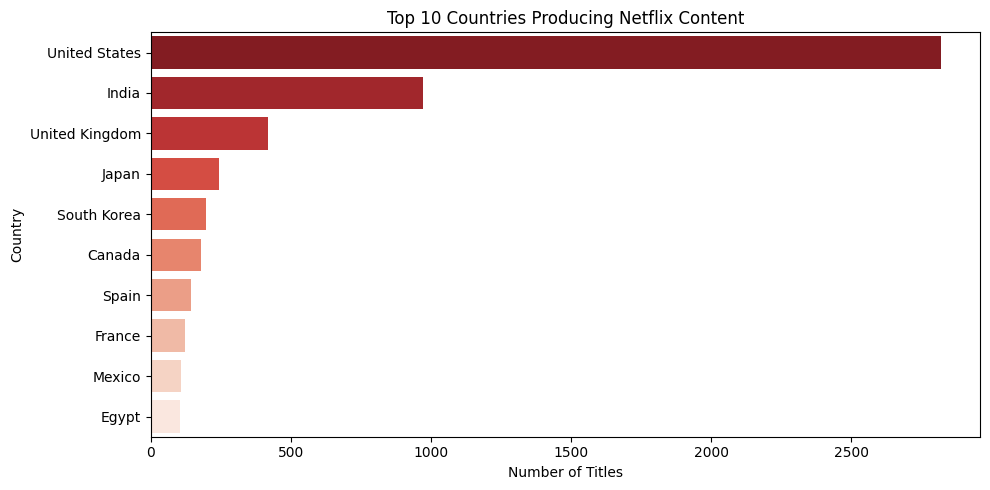

In [8]:
plt.figure(figsize=(10, 5))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Step 5: Content Added Over the Years

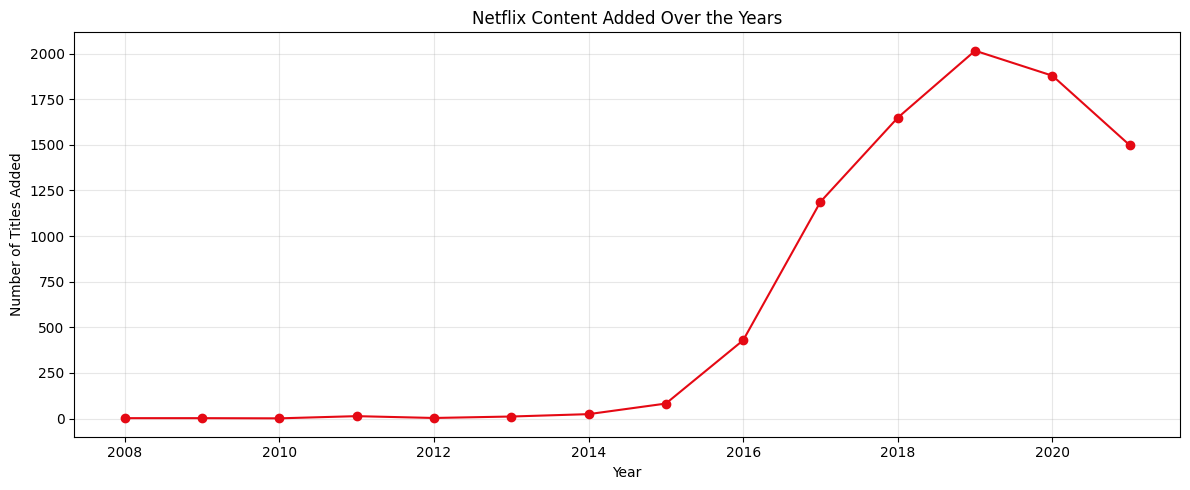

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(12, 5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914')
plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Top 10 Genres

/tmp/ipykernel_2633/1902053579.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='Count', y='Genre', palette='Reds_r')


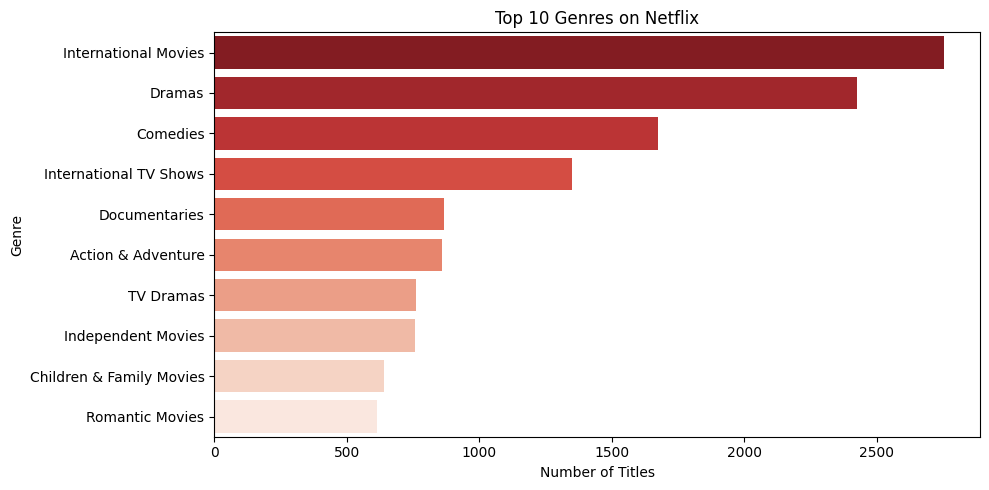

In [10]:
from collections import Counter

genres = df['listed_in'].dropna().str.split(', ')
all_genres = [genre for sublist in genres for genre in sublist]
genre_counts = Counter(all_genres)
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_genres, x='Count', y='Genre', palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Step 7: Key Insights

In [11]:
print("=== KEY INSIGHTS ===")
print(f"\n1. Total titles on Netflix: {len(df)}")
print(f"2. Movies: {df[df['type']=='Movie'].shape[0]} | TV Shows: {df[df['type']=='TV Show'].shape[0]}")
print(f"3. Top producing country: {df['country'].value_counts().index[0]}")
print(f"4. Peak content addition year: {int(df['year_added'].value_counts().index[0])}")
print(f"5. Most popular genre: {top_genres.iloc[0]['Genre']}")

=== KEY INSIGHTS ===

1. Total titles on Netflix: 8807
2. Movies: 6131 | TV Shows: 2676
3. Top producing country: United States
4. Peak content addition year: 2019
5. Most popular genre: International Movies
